# Projeto 1 — Notebook 03 · Temas sem rótulo e recomendações de marketing

**Do texto à decisão: sentimento e temas nas avaliações da Americanas** · CDIA · PUC-SP · 2026.2
Equipe: Matheus Campos Amorim (00361482) · *(demais integrantes no README)*

Base: B2W-Reviews01 (REAL; OSHIRO; MAFRA, 2019), CC BY-NC-SA 4.0. Lê `artefatos/base_auditada.parquet` (notebook 01)
e `app/preproc.py` (notebook 02). Rode os dois antes.

**O que este notebook faz:**

1. **Temas-artefato primeiro:** NMF com o pré-processamento do classificador, para ver o que é só falta de limpeza.
2. **Recorte por polaridade:** NMF nas avaliações negativas e nas positivas, com o `k` escolhido por medida.
3. **Recorte por categoria** (`site_category_lv1`): NMF nas negativas de quatro categorias.
4. **Contraprova** (Prática 03): agrupamento hierárquico de Ward e K-Means sobre as mesmas negativas. Os temas estão
   nos dados ou no método?
5. **Tema × sentimento × categoria**, com famílias de assunto que existem nos dois lados.
6. **Recomendações** para a Americanas, com número, exemplo real e destinatário, e os **limites** da base.

**Por que NMF, e não LDA:** o NMF trabalha direto sobre a matriz TF-IDF que o notebook 02 já justificou, é
determinístico com `init="nndsvd"` e produz pesos não negativos fáceis de ler ("este texto é 70% tema 3"). O LDA
precisa de contagens brutas e de vários reinícios para estabilizar, e em textos curtos (mediana de 18 palavras aqui)
costuma dar temas mais difusos.

In [1]:
# ⟦célula 03.01⟧
import json, re, sys, time, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

SEMENTE = 42
for pasta in ["artefatos", "figuras", "app/modelos"]:
    Path(pasta).mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
AZUL, LARANJA, CINZA, VERDE = "#2E5E8C", "#C0592B", "#9A9A9A", "#4C8C4A"
pd.set_option("display.max_colwidth", 230)
def salvar(fig, nome):
    fig.savefig(f"figuras/{nome}.png", bbox_inches="tight", dpi=150); return f"figuras/{nome}.png"

assert Path("artefatos/base_auditada.parquet").exists() and Path("app/preproc.py").exists(), \
    "Rode 01_auditoria e 02_sentimento antes deste notebook."
sys.path.insert(0, "app"); import preproc; importlib.reload(preproc)
base = pd.read_parquet("artefatos/base_auditada.parquet")
decisoes = json.loads(Path("artefatos/decisoes.json").read_text())
df = base[base["no_modelo"]].reset_index(drop=True).copy()
print(f"{len(df):,} avaliações (1-2★ e 4-5★ · com texto · sem duplicata) · "
      f"{(df['classe'] == 'negativo').sum():,} negativas · {(df['classe'] == 'positivo').sum():,} positivas".replace(",", "."))
print(f"baseline do classificador (notebook 01): {decisoes['baseline_maioria']:.3f}")

110.874 avaliações (1-2★ e 4-5★ · com texto · sem duplicata) · 32.600 negativas · 78.274 positivas
baseline do classificador (notebook 01): 0.706


## 1. Duas limpezas, dois propósitos

O classificador do notebook 02 **precisa** de `nao`, `muito`, `mais`, `mas`: são as palavras que viram a polaridade.
Um modelo de temas pergunta outra coisa (*do que* o cliente fala), e para ele essas palavras são ruído que aparece em
todo texto. Por isso há dois pipelines, a partir do mesmo `preproc.normalizar`:

| | classificador (notebook 02) | temas (este notebook) |
|---|---|---|
| stop words | NLTK **menos** 11 protegidas | NLTK **completa** + palavras genéricas do domínio |
| `nao`, `muito`, `mais`, `mas` | ficam | saem |
| letra esticada | colapsada | colapsada (versão A mostra o que acontece sem) |

As palavras genéricas do domínio (`produto`, `pra`, `q`, `vc`…) foram acrescentadas **depois** de aparecerem como
artefato na seção 2. A lista está na célula abaixo, inteira.

In [2]:
# ⟦célula 03.02⟧
GENERICAS = set("produto produtos pra pro q vc ta to tá aqui la ai vai ter fazer fiz faz ser estar coisa vez".split())
STOP_TEMAS = preproc.STOPWORDS_NLTK | GENERICAS

t0 = time.time()
df["norm_cru"] = [preproc.normalizar(t, esticada=False, caixa_alta=False) for t in df["review_text"]]  # sem colapsar
df["norm"]     = [preproc.normalizar(t, esticada=True,  caixa_alta=False) for t in df["review_text"]]
df["doc_clf"]   = [" ".join(preproc.tokenizar(s, stop=preproc.STOPWORDS)) for s in df["norm_cru"]]   # pipeline do 02, sem colapsar
df["doc_temas"] = [" ".join(w for w in s.split() if w not in STOP_TEMAS) for s in df["norm"]]
print(f"({time.time() - t0:.0f} s) · palavras por avaliação (mediana): texto {df['norm'].str.split().str.len().median():.0f} "
      f"· doc de temas {df['doc_temas'].str.split().str.len().median():.0f}")

(7 s) · palavras por avaliação (mediana): texto 16 · doc de temas 9


In [3]:
# ⟦célula 03.03⟧
def ajustar_nmf(docs, k, min_df=10, max_df=0.5, ngram=(1, 2)):
    vet = TfidfVectorizer(token_pattern=r"\S+", lowercase=False, min_df=min_df, max_df=max_df, ngram_range=ngram)
    X = vet.fit_transform(docs)
    nmf = NMF(n_components=k, init="nndsvd", random_state=SEMENTE, max_iter=500)
    W = nmf.fit_transform(X)
    return vet, nmf, X, W

def top_termos(vet, nmf, n=10):
    f = vet.get_feature_names_out()
    return [[f[j] for j in c.argsort()[::-1][:n]] for c in nmf.components_]

def tabela_temas(vet, nmf, W, nomes=None, n=10):
    dominante = W.argmax(axis=1)
    sem_tema = W.sum(axis=1) == 0
    linhas = []
    for i, termos in enumerate(top_termos(vet, nmf, n)):
        linhas.append({"tema": i, "nome": (nomes or {}).get(i, "—"),
                       "% das avaliações": round(100 * np.mean((dominante == i) & ~sem_tema), 1),
                       "termos mais pesados": " · ".join(termos)})
    return pd.DataFrame(linhas).set_index("tema")

def exemplos(textos, W, tema, n=3, min_pal=6, max_pal=60):
    # avaliações em que o tema é DOMINANTE (≥ 60% do peso), de tamanho legível, ordenadas pelo peso
    share = W[:, tema] / np.maximum(W.sum(axis=1), 1e-12)
    tam = np.array([len(t.split()) for t in textos])
    ok = np.where((share >= 0.6) & (tam >= min_pal) & (tam <= max_pal))[0]
    ordem = ok[np.argsort(-W[ok, tema])][:n]
    return [textos[i] for i in ordem]
print("funções prontas")

funções prontas


---
## 2. Temas-artefato: o que aparece quando a limpeza é a do classificador

NMF com `k = 8` nas avaliações **negativas**, usando o pipeline do notebook 02 **sem colapsar** a letra esticada.

In [4]:
# ⟦célula 03.04⟧
neg = df[df["classe"] == "negativo"].reset_index(drop=True)
pos = df[df["classe"] == "positivo"].reset_index(drop=True)
vetA, nmfA, XA, WA = ajustar_nmf(neg["doc_clf"], 8)
tabela_temas(vetA, nmfA, WA)

,nome,% das avaliações,termos mais pesados
tema,,,
0,—,4.9,recebi · nao recebi · recebi produto · produto nao · ainda · ainda nao · produto ate · paguei · recebi nao · momento nao
1,—,37.8,mais · americanas · comprei · ja · dias · compra · mas · site · nem · loja
2,—,15.3,muito · ruim · muito ruim · gostei · nao gostei · mas · produto muito · fragil · bem · bom
3,—,7.7,ainda · ainda nao · chegou · nao chegou · produto ainda · entrega · prazo · prazo entrega · mes · dia
4,—,11.5,veio · defeito · veio defeito · produto veio · troca · nao veio · defeito nao · faltando · funciona · nao funciona
5,—,4.0,avaliar · posso · posso avaliar · nao posso · avaliar produto · produto nao · pois · nao avaliar · entregue · nao entregue
6,—,8.1,ate · ate agora · agora · hoje · dia · ate hoje · agora nao · hoje nao · nada · agora nada
7,—,10.7,qualidade · recomendo · nao recomendo · pessima · pessima qualidade · produto pessima · qualidade nao · material · ninguem · baixa


In [5]:
# ⟦célula 03.05⟧
# letra esticada e nome de produto: quanto do vocabulário eles ocupam?
f = vetA.get_feature_names_out()
esticadas = [t for t in f if preproc.ESTICADA.search(t)]
print(f"termos com letra esticada no vocabulário do NMF (min_df=10): {len(esticadas)} → {esticadas[:15]}")
pesos_esticada = nmfA.components_[:, [list(f).index(t) for t in esticadas]].max() if esticadas else 0
print(f"maior peso de um termo esticado em qualquer tema: {pesos_esticada:.3f} "
      f"(o 10º termo de cada tema pesa, em média, {np.mean([np.sort(c)[-10] for c in nmfA.components_]):.3f})")

termos com letra esticada no vocabulário do NMF (min_df=10): 3 → ['kkk', 'kkkk', 'kkkkk']
maior peso de um termo esticado em qualquer tema: 0.004 (o 10º termo de cada tema pesa, em média, 0.314)


**Três temas-artefato, e um que não apareceu** (⟦células 03.04 e 03.05⟧). Com a limpeza do classificador:

* **Tema 1 (37,8% das negativas!): palavra de função.** `mais · americanas · comprei · ja · dias · compra · mas · site ·
  nem · loja`. Não é um assunto: é o vocabulário de qualquer reclamação. As palavras protegidas (`mais`, `mas`, `ja`,
  `nem`), essenciais para o classificador, dominam o maior tema e o esvaziam.
* **Tema 6 (8,1%): advérbio de tempo.** `ate · ate agora · agora · hoje · dia · ate hoje · nada`. A **forma** de uma
  reclamação de espera, não o **objeto**. O que espera (entrega, troca, reembolso) fica diluído.
* **Tema 2 (15,3%): intensificador + polaridade.** `muito · ruim · muito ruim · gostei · nao gostei · mas · bem · bom`.
  É o sentimento de novo, e não o assunto: o classificador já faz esse trabalho.
* **Letra esticada: não virou artefato.** Sem colapsar, só 3 formas esticadas passam pelo `min_df=10` (`kkk`, `kkkk`,
  `kkkkk`), e o maior peso de qualquer uma delas num tema é **0,004**, contra 0,314 do 10º termo médio. A auditoria
  explica: letra esticada de verdade está em só 2.081 avaliações, espalhada em formas diferentes. Colapsamos assim
  mesmo, por coerência com o notebook 02.
* **Nome de produto repetido** aparece nos recortes por categoria (seção 4: `celular · aparelho`, `impressora · hp`) e é
  tratado lá.

**Decisão:** o pipeline de temas usa a lista **completa** do NLTK (sem proteger `nao`, `mais`, `mas`, `muito`) mais 20
palavras genéricas do domínio (⟦célula 03.02⟧). Os três temas-artefato desaparecem na seção 3.

---
## 3. Recorte por polaridade — escolha do `k`

Com o pipeline de temas, para `k` de 4 a 16, nas **negativas** e nas **positivas**, três medidas:

* **erro de reconstrução** do NMF: sempre cai com `k` (mais temas sempre explicam mais), então serve só para ver
  onde a queda **desacelera**;
* **coerência UMass** dos 10 termos de cada tema, a média sobre os temas: quanto os termos de um tema aparecem
  **juntos nos mesmos textos** (mais perto de zero é melhor). É a medida que pune tema "colcha de retalhos";
* **redundância**: o maior cosseno entre dois temas. Perto de 1, dois temas dizem a mesma coisa.

Nenhuma das três decide sozinha (é a lição do `k` da Prática 03). A decisão final vem da **leitura** dos temas em dois
valores de `k`, na seção 3.1.

In [6]:
# ⟦célula 03.06⟧
def coerencia_umass(X, vet, nmf, n=10):
    Xb = (X > 0).astype(np.int32).tocsc()
    df_ = np.asarray(Xb.sum(axis=0)).ravel()
    notas = []
    for c in nmf.components_:
        top = c.argsort()[::-1][:n]
        sub = Xb[:, top]
        co = (sub.T @ sub).toarray()
        s = [np.log((co[i, j] + 1) / df_[top[j]]) for i in range(1, n) for j in range(i)]
        notas.append(np.mean(s))
    return float(np.mean(notas))

def redundancia(nmf):
    C = normalize(nmf.components_)
    S = C @ C.T; np.fill_diagonal(S, 0)
    return float(S.max())

linhas = []
t0 = time.time()
for nome, recorte in [("negativas", neg), ("positivas", pos)]:
    vet = TfidfVectorizer(token_pattern=r"\S+", lowercase=False, min_df=10, max_df=0.5, ngram_range=(1, 2))
    X = vet.fit_transform(recorte["doc_temas"])
    for k in [4, 6, 8, 10, 12, 16]:
        nmf = NMF(n_components=k, init="nndsvd", random_state=SEMENTE, max_iter=500).fit(X)
        linhas.append((nome, k, nmf.reconstruction_err_, coerencia_umass(X, vet, nmf), redundancia(nmf)))
escolha_k = pd.DataFrame(linhas, columns=["recorte", "k", "erro de reconstrução", "coerência UMass", "redundância máx."])
print(f"({time.time() - t0:.0f} s)")
escolha_k.round(3)

(41 s)


,recorte,k,erro de reconstrução,coerência UMass,redundância máx.
0,negativas,4,178.085,-2.545,0.187
1,negativas,6,177.492,-2.597,0.194
2,negativas,8,176.955,-2.760,0.201
3,negativas,10,176.477,-2.836,0.192
4,negativas,12,176.040,-3.010,0.188
5,negativas,16,175.245,-2.991,0.148
6,positivas,4,274.303,-2.376,0.146
7,positivas,6,272.795,-2.678,0.127
8,positivas,8,271.541,-2.916,0.130
9,positivas,10,270.430,-3.056,0.264


figuras/03_escolha_k.png


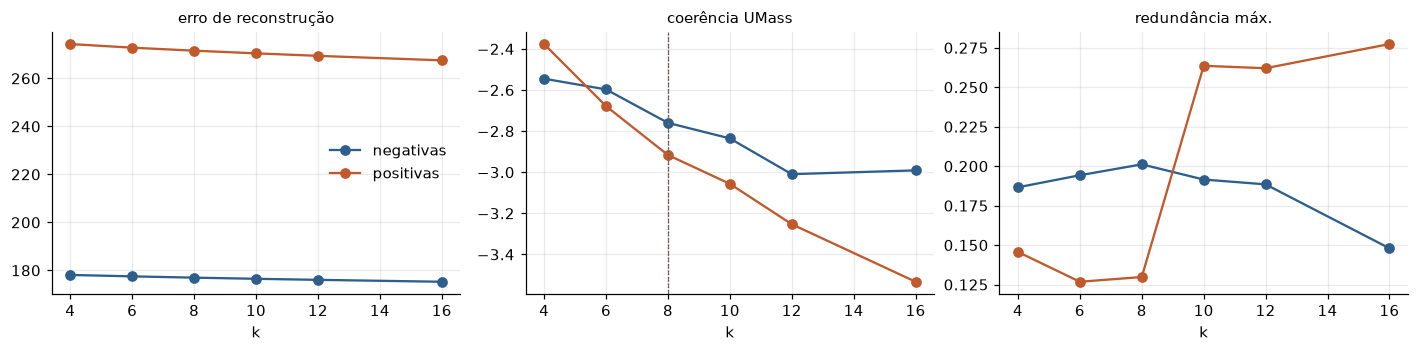

In [7]:
# ⟦célula 03.07⟧
fig, eixos = plt.subplots(1, 3, figsize=(13, 3.3))
for (nome, g), cor in zip(escolha_k.groupby("recorte"), [AZUL, LARANJA]):
    for eixo, col in zip(eixos, ["erro de reconstrução", "coerência UMass", "redundância máx."]):
        eixo.plot(g["k"], g[col], marker="o", color=cor, label=nome); eixo.set_title(col, fontsize=10); eixo.set_xlabel("k")
eixos[0].legend(frameon=False)
eixos[1].axvline(8, color=LARANJA, ls="--", lw=0.8); eixos[1].axvline(8, color=AZUL, ls=":", lw=0.8)
fig.tight_layout(); print(salvar(fig, "03_escolha_k")); plt.show()

### 3.1. Dois valores de `k` lidos lado a lado (negativas)

In [8]:
# ⟦célula 03.08⟧
K_ALT = 5
vet_alt, nmf_alt, X_alt, W_alt = ajustar_nmf(neg["doc_temas"], K_ALT)
print(f"k = {K_ALT}"); display(tabela_temas(vet_alt, nmf_alt, W_alt, n=8))
vetN, nmfN, XN, WN = ajustar_nmf(neg["doc_temas"], 8)
print(f"k = 8 (escolhido)")
tabela_temas(vetN, nmfN, WN, n=8)

k = 5


,nome,% das avaliações,termos mais pesados
tema,,,
0,—,31.7,americanas · dia · entrega · comprei · compra · dias · nada · chegou
1,—,12.4,recebi · ainda · ainda recebi · recebi ainda · mes · recebi recebi · hoje · avaliar ainda
2,—,35.0,qualidade · pessima · pessima qualidade · recomendo · ruim · material · bem · uso
3,—,16.0,veio · defeito · veio defeito · troca · faltando · devolucao · funciona · quebrado
4,—,4.8,avaliar · posso · posso avaliar · avaliar pois · pois · avaliar recebi · recebi posso · avaliar ainda


k = 8 (escolhido)


,nome,% das avaliações,termos mais pesados
tema,,,
0,—,12.6,americanas · site · compra · loja · lojas · nada · contato · agora
1,—,10.1,recebi · ainda · ainda recebi · recebi ainda · mes · recebi recebi · comprei · avaliar ainda
2,—,5.8,qualidade · pessima · pessima qualidade · material · recomendo · baixa · baixa qualidade · ruim
3,—,11.9,veio · defeito · veio defeito · troca · faltando · devolucao · quebrado · veio faltando
4,—,4.2,avaliar · posso · posso avaliar · avaliar pois · pois · avaliar recebi · recebi posso · avaliar ainda
5,—,9.9,entrega · dia · chegou · prazo · hoje · prazo entrega · dias · ainda
6,—,40.8,uso · bem · comprei · aparelho · recomendo · ruim · funciona · celular
7,—,4.7,dinheiro · volta · dinheiro volta · quero · quero dinheiro · devolver · devolucao · dinheiro jogado


**Escolha do k** (⟦células 03.06 a 03.09⟧). As três medidas, lidas com a régua da Prática 03 (*"heurística, não prova"*):

* **Erro de reconstrução** cai devagar e sem cotovelo (negativas: 178,1 em k = 4 → 175,2 em k = 16). Não aponta k nenhum.
* **Coerência UMass** cai a cada k nos dois recortes (−2,55 → −2,99 nas negativas). É um viés conhecido da medida:
  temas mais largos têm termos mais frequentes, que co-ocorrem mais. Sozinha, ela sempre escolheria o menor k.
* **Redundância** é a que discrimina. Nas **positivas**, fica em 0,13 até k = 8 e **dobra em k = 10 (0,264)**: a partir
  daí dois temas dizem a mesma coisa. **k = 8 nas positivas.** Nas negativas, ela fica estável em 0,19–0,20 até k = 12.
  Não há temas repetidos até lá, e a decisão vai para a leitura.

**Leitura de k = 5 contra k = 8 nas negativas:**

* com **k = 5**, o tema 0 mistura `americanas · dia · entrega · comprei · compra · nada · chegou`: **atraso de entrega
  e reclamação contra a loja no mesmo tema** (31,7%). E não existe o tema "quero meu dinheiro de volta";
* com **k = 8**, essa mistura se separa em **"Loja, site e atendimento"** (12,6%) e **"Atraso e prazo de entrega"**
  (9,9%), e surge **"Quero meu dinheiro de volta"** (4,7%), com vocabulário próprio (`dinheiro volta`, `dinheiro jogado`).
  Os três exigem destinatários diferentes na empresa. É o critério de negócio da Prática 03: grupo que não muda a ação
  não vale a pena.

**k = 8 nos dois recortes.** O custo: o tema **"Funciona mal no uso" fica com 40,8%** das negativas. Ele é largo (tudo o
que é defeito de desempenho, de bateria de celular a TV lenta), mas coerente na leitura, e a seção 4 o abre por categoria.

### 3.2. Os temas das avaliações NEGATIVAS, nomeados, com três avaliações reais cada

In [9]:
# ⟦célula 03.09⟧
NOMES_NEG = {0: 'Loja, site e atendimento', 1: 'Não recebi o produto', 2: 'Qualidade e material ruins', 3: 'Veio com defeito ou faltando (troca)', 4: 'Pediram avaliação antes da entrega', 5: 'Atraso e prazo de entrega', 6: 'Funciona mal no uso', 7: 'Quero meu dinheiro de volta'}
tabela_temas(vetN, nmfN, WN, NOMES_NEG)

,nome,% das avaliações,termos mais pesados
tema,,,
0,"Loja, site e atendimento",12.6,americanas · site · compra · loja · lojas · nada · contato · agora · lojas americanas · nunca
1,Não recebi o produto,10.1,recebi · ainda · ainda recebi · recebi ainda · mes · recebi recebi · comprei · avaliar ainda · avaliacao · hoje
2,Qualidade e material ruins,5.8,qualidade · pessima · pessima qualidade · material · recomendo · baixa · baixa qualidade · ruim · material pessima · qualidade recomendo
3,Veio com defeito ou faltando (troca),11.9,veio · defeito · veio defeito · troca · faltando · devolucao · quebrado · veio faltando · pedi · solicitei
4,Pediram avaliação antes da entrega,4.2,avaliar · posso · posso avaliar · avaliar pois · pois · avaliar recebi · recebi posso · avaliar ainda · entregue · vou avaliar
5,Atraso e prazo de entrega,9.9,entrega · dia · chegou · prazo · hoje · prazo entrega · dias · ainda · ainda chegou · data
6,Funciona mal no uso,40.8,uso · bem · comprei · aparelho · recomendo · ruim · funciona · celular · bom · gostei
7,Quero meu dinheiro de volta,4.7,dinheiro · volta · dinheiro volta · quero · quero dinheiro · devolver · devolucao · dinheiro jogado · jogado · devolucao dinheiro


In [10]:
# ⟦célula 03.10⟧
textos_neg = neg["review_text"].tolist()
for i in range(8):
    print(f"■ TEMA {i} — {NOMES_NEG.get(i, '(sem nome)')}")
    for t in exemplos(textos_neg, WN, i):
        print("   ·", t[:230].replace("\n", " "))
    print()

■ TEMA 0 — Loja, site e atendimento
   · Lojas Americanas está expondo produto falsificado em seu site.
   · Ainda estou aguardando a resposta da troca do meu produto. Ninguém até agora resolveu me ligar o me dar alguma satisfação, por mim nunca mais compro nada nas lojas Americanas, pois seu atendimento pós compra é uma enganação, desac
   · Não sei se é problema da Americanas ou da loja,pq eu sempre comprei na Americanas e todos a vezes me mandaram  como estava minha compra só q agora fiz uma compra aqui e já está indo pra 3 dias quase e até agora nada.

■ TEMA 1 — Não recebi o produto
   · Não recebi o produto!!! O praz já estorou e ainda não recebi o meu produto!
   · Ainda não recebi o produto e  por isso não tenho como qualificar .
   · Ainda não recebi o produto !!!!! Ainda não recebi o produto!!!!!

■ TEMA 2 — Qualidade e material ruins
   · Produto de pessima qualidade em todos os sentidos, NÃO COMPREM!
   · Produto de péssima qualidade!  Praticamente as brocas e os bits são d

**Os 8 temas das avaliações negativas** (⟦células 03.09 e 03.10⟧), com o peso de cada um entre as 32.600 negativas:

| tema | nome | % | o que as avaliações reais dizem |
|---|---|---|---|
| 6 | **Funciona mal no uso** | 40,8 | *"trava muito com menos de 1 mês de uso, o touch não funciona"*; *"som é muito fraco"*; *"tv com processo muito lento"* |
| 0 | **Loja, site e atendimento** | 12,6 | *"Lojas Americanas está expondo produto falsificado em seu site"*; *"Ninguém até agora resolveu me ligar"* |
| 3 | **Veio com defeito ou faltando (troca)** | 11,9 | *"o produto veio com defeito, por isso fiz a devolutiva"*; *"PRODUTO VEIO COM DEFEITO… QUERO RESSARCIMENTO"* |
| 1 | **Não recebi o produto** | 10,1 | *"Não recebi o produto!!! O prazo já estourou"*; *"Ainda não recebi… não tenho como qualificar"* |
| 5 | **Atraso e prazo de entrega** | 9,9 | *"O prazo de entrega era pra dia 15 de fevereiro e ainda não chegou"*; *"Não respeitaram o prazo de entrega!"* |
| 2 | **Qualidade e material ruins** | 5,8 | *"Produto de péssima qualidade… as brocas e os bits são descartáveis"*; *"material é de péssima qualidade"* |
| 7 | **Quero meu dinheiro de volta** | 4,7 | *"Produto não é original, quero meu dinheiro de volta"*; *"quero meu dinheiro de volta o que eu faço para receber"* |
| 4 | **Pediram avaliação antes da entrega** | 4,2 | *"Quando o produto for entregue, eu até posso avaliar"*; *"Eu não posso avaliar um produto que eu não recebi"* |

Somando **Não recebi + Atraso + Pediram avaliação antes da entrega**, **24,2% das reclamações são sobre entrega, não
sobre o produto** (⟦célula 03.19⟧). E o tema 4 é um achado de processo: a Americanas **pede a avaliação de produtos que
ainda não chegaram**, e o cliente responde com 1 estrela para o produto que nunca viu.

Um tema nas negativas é parcialmente artefato do formulário: em *"PRODUTO VEIO COM DEFEITO .... QUERO RESSARCIMENTO"* e
*"O produto veio com defeito Fgyujhfdjkmbcxbkjgx…"*, o cliente escreve uma frase e enche o resto para atingir o tamanho
mínimo. A seção 6 mede isso.

### 3.3. Os temas das avaliações POSITIVAS

In [11]:
# ⟦célula 03.11⟧
NOMES_POS = {0: 'Entrega rápida', 1: 'Chegou antes do prazo', 2: 'Bom e bom preço (elogio curto)', 3: 'Ótima/boa qualidade', 4: 'Custo-benefício', 5: 'Atendeu ou superou as expectativas', 6: 'Recomendo (elogio genérico)', 7: 'Excelente qualidade'}
vetP, nmfP, XP, WP = ajustar_nmf(pos["doc_temas"], 8)
textos_pos = pos["review_text"].tolist()
display(tabela_temas(vetP, nmfP, WP, NOMES_POS))
for i in range(8):
    print(f"■ TEMA {i} — {NOMES_POS.get(i, '(sem nome)')}")
    for t in exemplos(textos_pos, WP, i):
        print("   ·", t[:200].replace("\n", " "))

,nome,% das avaliações,termos mais pesados
tema,,,
0,Entrega rápida,6.4,entrega · rapida · entrega rapida · super rapida · entrega super · rapida recomendo · bom entrega · americanas · parabens · qualidade entrega
1,Chegou antes do prazo,14.7,antes · prazo · antes prazo · chegou · chegou antes · bem · bem antes · previsto · entrega antes · entrega
2,Bom e bom preço (elogio curto),17.6,bom · bom recomendo · preco · bom entrega · bom bom · bom chegou · gostei · recomendo · aparelho · preco bom
3,Ótima/boa qualidade,10.6,qualidade · otima · otima qualidade · boa · boa qualidade · qualidade entrega · qualidade recomendo · qualidade chegou · excelente qualidade · preco
4,Custo-benefício,7.1,custo · beneficio · custo beneficio · otimo · otimo custo · excelente custo · bom custo · beneficio recomendo · melhor · melhor custo
5,Atendeu ou superou as expectativas,6.4,expectativas · atendeu · atendeu expectativas · superou · superou expectativas · todas · todas expectativas · expectativas recomendo · atendeu todas · bom atendeu
6,Recomendo (elogio genérico),26.5,recomendo · super · super recomendo · gostei · todos · otimo · recomendo todos · rapido · bem · amei
7,Excelente qualidade,10.5,excelente · excelente qualidade · qualidade · excelente recomendo · excelente entrega · recomendo · bom excelente · facil · compra · preco


■ TEMA 0 — Entrega rápida
   · Produto com qualidade e a entrega foi muito rápida.
   · Gostei muito do produto! O´tima qualidade e entrega rápida!!
   · Recomendo este produto. A entrega foi muito rápida.
■ TEMA 1 — Chegou antes do prazo
   · Chegou antes do prazo e o produto e o que esperava!
   · Produto chegou muito antes do prazo , minha irmãzinha amou!!!
   · produto muito bom o produto e chegou antes do prazo
■ TEMA 2 — Bom e bom preço (elogio curto)
   · Muito bom. Não tenho o que opnar. ————————————————
   · muito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommuito bommu
   · BOM PRA CURRÍCULO EDUCACIONAL EXTRACURRICULARES E BIBLIOTECAS !!!
■ TEMA 3 — Ótima/boa qualidade
   · produto de ótima qualidade. produto de ótima qualidade.
   · Produto de ótima qualidade, eu recomendo o produto
   · Produto de ótima qualidade !  Recomendo ......... ..

**Os 8 temas das avaliações positivas** (⟦célula 03.11⟧), entre as 78.274 positivas: **Recomendo (elogio genérico)**
26,5% · **Bom e bom preço** 17,6% · **Chegou antes do prazo** 14,7% · **Ótima/boa qualidade** 10,6% · **Excelente
qualidade** 10,5% · **Custo-benefício** 7,1% · **Entrega rápida** 6,4% · **Atendeu ou superou as expectativas** 6,4%.

Duas leituras:

* **Entrega também é o que se elogia:** *Chegou antes do prazo* + *Entrega rápida* = **21,1% das positivas**. É a
  mesma família que gera 24,2% das negativas. **A entrega decide a nota nos dois sentidos.**
* **Dois temas são, em parte, artefato do formulário.** Os exemplos de *"Recomendo"* e de *"Bom"* incluem *"Recomendo
  vgfrgjkgfewsdgj dfgjihfeesfjj…"*, *"muito bom MESMO MESMO MESMO MESMO…"* e *"ótimo produto pelo seu custo benefício
  asds ad asd ass"*: o cliente tem uma frase a dizer e enche o resto. Esses temas são nomeáveis (elogio genérico), mas
  **não contam um assunto** e não entram nas recomendações como assunto.

---
## 4. Recorte por categoria — do que se reclama em cada uma

Quatro categorias, escolhidas por volume e por taxa de reclamação (notebook 01, ⟦célula 01.21⟧): **Celulares e
Smartphones** (a maior, 20.859 avaliações), **Móveis** (a de maior % negativa entre as grandes, 45,3%), **Beleza e
Perfumaria** e **Informática e Acessórios** (32,8%). NMF com `k = 5` nas **negativas** de cada uma: a pergunta
de negócio por categoria é *o que consertar*.

In [12]:
# ⟦célula 03.12⟧
CATEGORIAS = ["Celulares e Smartphones", "Móveis", "Beleza e Perfumaria", "Informática e Acessórios"]
NOMES_CAT = {'Celulares e Smartphones': {0: 'Atraso na entrega', 1: 'Não recebi', 2: 'Pediram avaliação antes da entrega', 3: 'Veio com defeito (carregador)', 4: 'Bateria, tela e travamento no uso'}, 'Móveis': {0: 'Atraso na entrega', 1: 'Peças faltando e montagem', 2: 'Não recebi', 3: 'Material de má qualidade', 4: 'Pediram avaliação antes da entrega'}, 'Beleza e Perfumaria': {0: 'Atraso e compra pelo site/loja', 1: 'Não recebi / não posso avaliar', 2: 'Produtos para cabelo: resultado abaixo do esperado', 3: 'Veio com defeito (troca)', 4: 'Perfume: fixação, cheiro, original?'}, 'Informática e Acessórios': {0: 'Loja e dinheiro (genérico)', 1: 'Não recebi / não posso avaliar', 2: 'Defeito, cabo e devolução', 3: 'Cartucho e impressora: original?', 4: 'Atraso na entrega'}}
modelos_cat = {}
for cat in CATEGORIAS:
    sub = neg[neg["site_category_lv1"] == cat].reset_index(drop=True)
    v, m, X, W = ajustar_nmf(sub["doc_temas"], 5, min_df=5)
    modelos_cat[cat] = (v, m, W, sub)
    print(f"■ {cat} — {len(sub):,} avaliações negativas".replace(",", "."))
    display(tabela_temas(v, m, W, NOMES_CAT.get(cat), n=8))

■ Celulares e Smartphones — 3.868 avaliações negativas


,nome,% das avaliações,termos mais pesados
tema,,,
0,Atraso na entrega,23.3,dia · americanas · entrega · prazo · dias · comprei · compra · nada
1,Não recebi,9.7,recebi · ainda · ainda recebi · recebi ainda · mes · ainda chegou · quero · hoje
2,Pediram avaliação antes da entrega,3.7,avaliar · posso · posso avaliar · chegou · pois · avaliar recebi · vou avaliar · vou
3,Veio com defeito (carregador),11.8,veio · defeito · veio defeito · troca · carregador · chegou · chegou defeito · celular veio
4,"Bateria, tela e travamento no uso",51.2,celular · aparelho · bateria · tela · uso · qualidade · camera · problema


■ Móveis — 2.913 avaliações negativas


,nome,% das avaliações,termos mais pesados
tema,,,
0,Atraso na entrega,31.1,entrega · prazo · dia · americanas · compra · comprei · dias · nada
1,Peças faltando e montagem,32.5,veio · pecas · faltando · montagem · veio faltando · mesa · montar · cor
2,Não recebi,12.5,recebi · ainda · ainda recebi · recebi ainda · avaliacao · mes · avaliar · receber
3,Material de má qualidade,16.8,qualidade · pessima · pessima qualidade · material · recomendo · ruim · madeira · baixa
4,Pediram avaliação antes da entrega,7.2,avaliar · posso · posso avaliar · chegou · avaliar ainda · pois · ainda chegou · avaliar pois


■ Beleza e Perfumaria — 2.210 avaliações negativas


,nome,% das avaliações,termos mais pesados
tema,,,
0,Atraso e compra pelo site/loja,25.4,americanas · chegou · comprei · dia · site · compra · nada · agora
1,Não recebi / não posso avaliar,16.9,recebi · ainda · ainda recebi · avaliar · entrega · posso · prazo · posso avaliar
2,Produtos para cabelo: resultado abaixo do esperado,28.1,cabelo · esquenta · bem · alisa · escova · gostei · cabelos · chapinha
3,Veio com defeito (troca),14.3,veio · defeito · veio defeito · troca · funciona · outro · pedi · faltando
4,"Perfume: fixação, cheiro, original?",15.2,perfume · original · cheiro · fixacao · qualidade · pessima · parece · fixa


■ Informática e Acessórios — 2.227 avaliações negativas


,nome,% das avaliações,termos mais pesados
tema,,,
0,Loja e dinheiro (genérico),40.2,americanas · comprei · dinheiro · loja · funciona · recomendo · nada · site
1,Não recebi / não posso avaliar,14.7,recebi · ainda · ainda recebi · avaliar · posso · posso avaliar · avaliar ainda · avaliar recebi
2,"Defeito, cabo e devolução",11.0,veio · defeito · veio defeito · troca · cabo · devolver · outro · devolucao
3,Cartucho e impressora: original?,15.8,impressora · cartucho · cartuchos · original · hp · tinta · preto · impressao
4,Atraso na entrega,18.2,entrega · chegou · prazo · dia · entregue · dias · prazo entrega · hoje


In [13]:
# ⟦célula 03.13⟧
for cat in CATEGORIAS:
    v, m, W, sub = modelos_cat[cat]
    print(f"\n■■ {cat}")
    for i in range(5):
        nome = NOMES_CAT.get(cat, {}).get(i, "(sem nome)")
        print(f"  tema {i} — {nome}")
        for t in exemplos(sub["review_text"].tolist(), W, i):
            print("     ·", t[:190].replace("\n", " "))


■■ Celulares e Smartphones
  tema 0 — Atraso na entrega
     · COMPREI DIA 24/04/2018, QUANDO COMPRA DIZ QUE É DE 07 Á 10 DIAS O PRAZO DA ENTREGA...HOJE JÁ É DIA 10/05 E NADA...
     · Comprei o celular dia 17 /03 paguei entrega expressa para receber até dia 02/04. Mas hoje é dia 16/04 eu não recebi o produto. Falaram q tentaram uma entrega dia dia 21/03 mas ninguém entrou
     · A americanas não cumpre com o prazo de entrega então não recomendo comprar na americanas era pra eu receber produto ate dia 10/05/2018 e ate agora nada e nem satisfação eles dar.
  tema 1 — Não recebi
     · Ainda nem recebi o produto, como vou aproveitar????????
     · Ainda não recebi o produto, só avaliarei quando receber.
     · Não tenho como gostar de um produto se não recebi .
  tema 2 — Pediram avaliação antes da entrega
     · Como posso avaliar se não recebei o produto.ja o atendimento ao cliente, posso avaliar que é pescimo
     · Como posso avaliar um produto que não consegui receber???????
     ·

**O que cada categoria tem de próprio** (⟦células 03.12 e 03.13⟧). Os temas de entrega se repetem nas quatro (atraso,
não recebi, avaliação antes da entrega). O que interessa é o que **só aparece numa**:

| categoria | tema próprio | % das negativas da categoria | avaliação real |
|---|---|---|---|
| **Móveis** (52,4% de negativas) | **Peças faltando e montagem** | **32,5** | *"ODIEI! Veio faltando muitas peças. Parafusos e a parte de trás do guarda-roupa."* · *"Veio faltando peças! 1 mês parado sem montar"* · *"veio sem fundo e as furações não batem"* |
| **Celulares** | **Bateria, tela e travamento no uso** | **51,2** | *"A bateria em menos de um mês apresentou problemas"* · *"com menos de 30 dias de uso a tela travou"* · *"bateria não dura carregada, carregador deu defeito"* |
| **Beleza e Perfumaria** | **Perfume: fixação, cheiro, original?** | **15,2** | *"O perfume não é original, péssima qualidade, não fixa na pele"* · *"Uso esse perfume há bastante tempo, e esse que comprei não tem fixação nenhuma"* |
| **Informática e Acessórios** | **Cartucho e impressora: original?** | **15,8** | *"a impressora acusa como cartucho falsificado"* · *"comparando com o cartucho que está na impressora, ele não é igual ao original"* |

**Temas-artefato por categoria:** os termos `celular · aparelho` (Celulares) e `impressora · hp` (Informática) são o
**nome do produto repetido**, e não o assunto. Eles aparecem porque o `max_df=0,5` é calculado dentro de cada recorte, e
lá o nome do produto já não é tão comum. Em Celulares, o tema 4 só foi nomeável porque os termos seguintes (`bateria ·
tela · camera · problema`) e as avaliações reais contam um assunto. Em Informática, o tema 0 (*"Loja e dinheiro"*,
40,2%) é largo demais para virar recomendação e fica declarado como genérico.

**Um assunto que atravessa duas categorias: autenticidade.** Perfume "não original" e cartucho "falsificado" são o
mesmo problema em produtos diferentes, e aparecem com vocabulário próprio. Somam-se ao *"expondo produto falsificado
em seu site"* do tema 0 das negativas.

---
## 5. Contraprova: agrupamento hierárquico (Ward) e K-Means — a ficha da Prática 03

Se os temas do NMF são estrutura dos dados e não invenção do método, um algoritmo **completamente diferente** deve
encontrar grupos parecidos. Seguimos a ficha de decisões da Prática 03:

* **Amostra:** 3.000 avaliações negativas (semente 42). Com as 32 mil, seriam ~530 milhões de pares de distâncias —
  a frase 3 da ficha da Prática 03: *"com base grande, construir a árvore sobre uma amostra"*.
* **Representação:** a matriz TF-IDF do recorte negativo reduzida a 100 dimensões por SVD (LSA) e normalizada a
  comprimento 1. Assim a distância euclidiana equivale ao cosseno, e o **Ward** (que exige euclidiana, Parte 6 da
  Prática 03) é legítimo.
* **Corte:** maior salto nas últimas fusões, conferido com a silhueta e com uma **base sem estrutura** (as colunas da
  LSA embaralhadas independentemente), como a contraprova da `clientes_bruto` na Tarefa 4.3.
* **Comparação:** ARI entre Ward, K-Means e o tema dominante do NMF.

In [14]:
# ⟦célula 03.14⟧
rng = np.random.default_rng(SEMENTE)
amostra = np.sort(rng.choice(len(neg), size=3000, replace=False))
svd = TruncatedSVD(n_components=100, random_state=SEMENTE).fit(XN)
L = normalize(svd.transform(XN[amostra]))
print(f"LSA: 100 dimensões explicam {svd.explained_variance_ratio_.sum():.1%} da variância do TF-IDF negativo")

Z = linkage(L, method="ward")
alturas = Z[:, 2]
saltos = np.diff(alturas, prepend=0)
ultimas = 15
j = len(alturas) - ultimas + int(saltos[-ultimas:].argmax())
k_salto = len(L) - j

# contraprova: mesma matriz, cada coluna embaralhada -> sem co-ocorrência, sem grupos
L_nulo = normalize(np.column_stack([rng.permutation(L[:, c]) for c in range(L.shape[1])]))
Z_nulo = linkage(L_nulo, method="ward")
saltos_nulo = np.diff(Z_nulo[:, 2], prepend=0)

print("últimas 12 alturas (dados):    ", alturas[-12:].round(2))
print("últimas 12 alturas (embaralh.):", Z_nulo[-12:, 2].round(2))
print(f"maior salto nas últimas {ultimas} fusões: dados {saltos[-ultimas:].max():.2f} (→ k = {k_salto}) · "
      f"embaralhado {saltos_nulo[-ultimas:].max():.2f}")

LSA: 100 dimensões explicam 16.7% da variância do TF-IDF negativo
últimas 12 alturas (dados):     [6.27 6.33 6.37 6.5  6.58 6.61 6.62 7.25 7.69 8.35 8.79 9.91]
últimas 12 alturas (embaralh.): [3.46 3.47 3.61 3.65 3.74 3.75 4.01 4.2  4.52 5.19 5.36 8.8 ]
maior salto nas últimas 15 fusões: dados 1.13 (→ k = 2) · embaralhado 3.45


figuras/03_saltos_ward.png


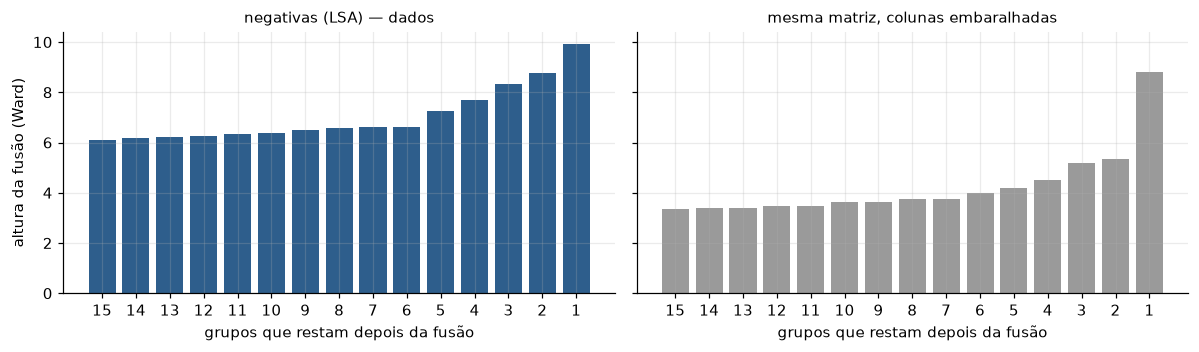

In [15]:
# ⟦célula 03.15⟧
restam = np.arange(15, 0, -1)
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.3), sharey=True)
eixos[0].bar(restam, alturas[-15:], color=AZUL); eixos[0].set_title("negativas (LSA) — dados", fontsize=10)
eixos[1].bar(restam, Z_nulo[-15:, 2], color=CINZA); eixos[1].set_title("mesma matriz, colunas embaralhadas", fontsize=10)
for e in eixos: e.set_xticks(restam); e.invert_xaxis(); e.set_xlabel("grupos que restam depois da fusão")
eixos[0].set_ylabel("altura da fusão (Ward)")
fig.tight_layout(); print(salvar(fig, "03_saltos_ward")); plt.show()

In [16]:
# ⟦célula 03.16⟧
dominante_nmf = WN[amostra].argmax(axis=1)
linhas = []
for k in [4, 6, 8, 10, 12]:
    r_ward = fcluster(Z, t=k, criterion="maxclust")
    km = KMeans(n_clusters=k, n_init=20, random_state=SEMENTE).fit(L)
    tam = sorted(np.bincount(r_ward)[1:].tolist(), reverse=True)
    linhas.append((k, silhouette_score(L, r_ward), silhouette_score(L, km.labels_),
                   silhouette_score(L_nulo, fcluster(Z_nulo, t=k, criterion="maxclust")),
                   adjusted_rand_score(r_ward, km.labels_), adjusted_rand_score(r_ward, dominante_nmf),
                   adjusted_rand_score(km.labels_, dominante_nmf), " · ".join(map(str, tam))))
contraprova = pd.DataFrame(linhas, columns=["k", "silhueta Ward", "silhueta K-Means", "silhueta (embaralhado)",
                                            "ARI Ward×KMeans", "ARI Ward×NMF", "ARI KMeans×NMF", "tamanhos Ward"])
contraprova.round(3)

,k,silhueta Ward,silhueta K-Means,silhueta (embaralhado),ARI Ward×KMeans,ARI Ward×NMF,ARI KMeans×NMF,tamanhos Ward
0,4,0.013,0.032,0.004,0.344,0.191,0.486,1460 · 1153 · 215 · 172
1,6,0.016,0.036,0.001,0.258,0.246,0.453,1334 · 1063 · 215 · 172 · 126 · 90
2,8,0.018,0.040,-0.001,0.204,0.241,0.433,1282 · 1015 · 215 · 172 · 126 · 90 · 52 · 48
3,10,0.018,0.044,-0.003,0.178,0.260,0.403,1144 · 1015 · 215 · 172 · 138 · 90 · 76 · 52 · 50 · 48
4,12,0.022,0.049,-0.003,0.189,0.291,0.371,975 · 818 · 326 · 215 · 172 · 138 · 90 · 76 · 52 · 50 · 48 · 40


In [17]:
# ⟦célula 03.17⟧
# no k do NMF: cada grupo do Ward cai em que tema do NMF?
r_ward = fcluster(Z, t=8, criterion="maxclust")
tab = pd.crosstab(pd.Series(r_ward, name="grupo Ward"),
                  pd.Series([NOMES_NEG.get(t, t) for t in dominante_nmf], name="tema dominante do NMF"))
pureza = tab.max(axis=1).sum() / tab.values.sum()
print(f"pureza: {pureza:.1%} das avaliações estão no tema NMF mais comum do seu grupo Ward")
tab

pureza: 54.7% das avaliações estão no tema NMF mais comum do seu grupo Ward


tema dominante do NMF,Atraso e prazo de entrega,Funciona mal no uso,"Loja, site e atendimento",Não recebi o produto,Pediram avaliação antes da entrega,Qualidade e material ruins,Quero meu dinheiro de volta,Veio com defeito ou faltando (troca)
grupo Ward,,,,,,,,
1,2,7,2,0,1,2,2,156
2,1,2,0,0,1,81,1,4
3,2,32,6,3,0,3,1,1
4,25,807,24,13,7,37,17,85
5,5,2,4,120,82,0,1,1
6,0,35,0,2,0,5,78,6
7,20,6,9,7,3,3,1,3
8,240,312,348,144,48,23,48,119


**O que a contraprova diz** (⟦células 03.14 a 03.17⟧), seguindo a ficha da Prática 03:

1. **O maior salto não decide aqui.** Nas negativas, as últimas alturas sobem em **rampa** (6,27 → 9,91), e o maior salto
   das últimas 15 fusões é **1,13**, apontando k = 2. A matriz **embaralhada** tem um salto final **maior** (3,45). É o
   desenho do `clientes_bruto` da Tarefa 4.3, e não o do `clientes_segmentos`: **texto não forma grupos compactos e
   separados**. Uma avaliação fala de entrega *e* de defeito *e* de reembolso ao mesmo tempo.
2. **Mas há estrutura, fraca e real.** A silhueta é baixa (Ward 0,013–0,022; K-Means 0,032–0,049), mas fica **sempre
   acima** da matriz embaralhada (0,004 a −0,003), que é o valor de "não há nada aqui".
3. **Ward encontra 5 dos 8 temas do NMF por conta própria.** Na tabela de contingência em k = 8: o grupo 1 é **91%**
   *Veio com defeito* (156 de 172); o grupo 2, **90%** *Qualidade e material* (81 de 90); o grupo 6, **62%** *Quero meu
   dinheiro de volta* (78 de 126); o grupo 5 junta *Não recebi* e *Pediram avaliação antes da entrega* (202 de 215, os
   dois temas que dizem "não chegou"); o grupo 4 é **80%** *Funciona mal no uso* (807 de 1.015). O que **não** separa:
   *Loja/atendimento* e *Atraso*, que ficam no grupo 8, o grande resto (1.282 avaliações). São justamente os temas com
   vocabulário mais genérico.
4. **K-Means concorda mais com o NMF (ARI 0,43–0,49) do que com o Ward (0,18–0,34).** Faz sentido: K-Means e NMF
   otimizam reconstrução em torno de "centros" (centroide × componente), e Ward funde por variância. Pureza do Ward
   contra o NMF: 54,7%.

**Conclusão da contraprova:** os temas do NMF não são invenção do método. Um algoritmo de outra família reencontra os
mais específicos (defeito, qualidade, reembolso, não recebido) quase puros. Mas a base não tem a estrutura de grupos
duros que justificaria entregar uma **partição**. **Para texto, o NMF (cada avaliação é uma mistura de temas) é a
ferramenta certa; o hierárquico é a contraprova, não o resultado.** É a frase 2 da ficha da Prática 03 com outra base:
*escolher o critério é escolher o formato de grupo que você aceita como legítimo*.

---
## 6. Tema × sentimento × categoria

Um NMF único nas 110.874 avaliações foi testado e **descartado**: com 70,6% de positivas, ele gasta quase todos os
temas com variações de elogio e junta as reclamações num tema só (ver ⟦célula 03.18⟧ abaixo, mantida como registro).
O cruzamento usa então os **dois modelos por polaridade** da seção 3, agrupados em **famílias** de assunto que existem
dos dois lados (a entrega é elogiada *e* criticada). Cada avaliação recebe o seu tema dominante.

In [18]:
# ⟦célula 03.18⟧
vetG, nmfG, XG, WG = ajustar_nmf(df["doc_temas"], 10)
tabela_temas(vetG, nmfG, WG, n=8)

,nome,% das avaliações,termos mais pesados
tema,,,
0,—,3.9,custo · beneficio · custo beneficio · otimo · otimo custo · excelente custo · bom custo · beneficio recomendo
1,—,8.8,antes · prazo · antes prazo · chegou · chegou antes · previsto · entrega antes · entrega
2,—,6.7,entrega · rapida · entrega rapida · super rapida · entrega super · bom entrega · rapida recomendo · qualidade entrega
3,—,7.6,qualidade · otima · otima qualidade · boa · boa qualidade · qualidade recomendo · qualidade entrega · qualidade chegou
4,—,30.4,recebi · ainda · americanas · comprei · dia · avaliar · compra · ainda recebi
5,—,9.2,bom · bom recomendo · preco · bom entrega · recomendo · bom bom · bom chegou · preco bom
6,—,8.0,recomendo · super · super recomendo · todos · recomendo todos · otimo · entrega super · super rapida
7,—,3.9,expectativas · atendeu · atendeu expectativas · superou · superou expectativas · todas · todas expectativas · expectativas recomendo
8,—,6.8,excelente · excelente qualidade · qualidade · excelente recomendo · excelente entrega · recomendo · bom excelente · facil


In [19]:
# ⟦célula 03.19⟧
FAMILIA_NEG = {0: 'Atendimento e loja', 1: 'Entrega', 2: 'Qualidade', 3: 'Defeito, peça faltando e troca', 4: 'Entrega', 5: 'Entrega', 6: 'Desempenho no uso', 7: 'Reembolso'}
FAMILIA_POS = {0: 'Entrega', 1: 'Entrega', 2: 'Elogio genérico', 3: 'Qualidade', 4: 'Preço e custo-benefício', 5: 'Expectativa', 6: 'Elogio genérico', 7: 'Qualidade'}
neg["tema"] = np.where(WN.sum(axis=1) > 0, WN.argmax(axis=1), -1)
pos["tema"] = np.where(WP.sum(axis=1) > 0, WP.argmax(axis=1), -1)
neg["nome_tema"] = neg["tema"].map(lambda t: NOMES_NEG.get(t, "sem tema"))
pos["nome_tema"] = pos["tema"].map(lambda t: NOMES_POS.get(t, "sem tema"))
neg["familia"] = neg["tema"].map(lambda t: FAMILIA_NEG.get(t, "sem tema"))
pos["familia"] = pos["tema"].map(lambda t: FAMILIA_POS.get(t, "sem tema"))
todas = pd.concat([neg, pos], ignore_index=True)

fam = pd.crosstab(todas["familia"], todas["classe"])
fam["total"] = fam.sum(axis=1)
fam["% negativas na família"] = (100 * fam["negativo"] / fam["total"]).round(1)
fam["% de todas as negativas"] = (100 * fam["negativo"] / len(neg)).round(1)
fam["% de todas as positivas"] = (100 * fam["positivo"] / len(pos)).round(1)
fam.sort_values("negativo", ascending=False)

classe,negativo,positivo,total,% negativas na família,% de todas as negativas,% de todas as positivas
familia,,,,,,
Desempenho no uso,13312,0,13312,100.0,40.8,0.0
Entrega,7882,16515,24397,32.3,24.2,21.1
Atendimento e loja,4109,0,4109,100.0,12.6,0.0
"Defeito, peça faltando e troca",3870,0,3870,100.0,11.9,0.0
Qualidade,1875,16506,18381,10.2,5.8,21.1
Reembolso,1532,0,1532,100.0,4.7,0.0
sem tema,20,128,148,13.5,0.1,0.2
Elogio genérico,0,34521,34521,0.0,0.0,44.1
Expectativa,0,5025,5025,0.0,0.0,6.4


In [20]:
# ⟦célula 03.20⟧
TOP_CATS = df["site_category_lv1"].value_counts().head(10).index
cruz = pd.crosstab(neg["site_category_lv1"], neg["nome_tema"], normalize="index").mul(100).round(1).loc[TOP_CATS]
cruz = cruz[[NOMES_NEG[i] for i in range(len(NOMES_NEG))]]
info = pd.DataFrame({"negativas": neg["site_category_lv1"].value_counts().loc[TOP_CATS],
                     "% negativas na categoria": df.groupby("site_category_lv1")["classe"]
                         .apply(lambda s: (s == "negativo").mean() * 100).loc[TOP_CATS].round(1)})
print("Entre as avaliações NEGATIVAS de cada categoria, % por tema dominante (10 maiores categorias):")
pd.concat([info, cruz], axis=1)

Entre as avaliações NEGATIVAS de cada categoria, % por tema dominante (10 maiores categorias):


,negativas,% negativas na categoria,"Loja, site e atendimento",Não recebi o produto,Qualidade e material ruins,Veio com defeito ou faltando (troca),Pediram avaliação antes da entrega,Atraso e prazo de entrega,Funciona mal no uso,Quero meu dinheiro de volta
site_category_lv1,,,,,,,,,,
Celulares e Smartphones,3868,21.6,11.7,7.1,3.6,10.7,3.2,11.2,48.9,3.6
Eletroportáteis,1928,19.2,9.7,6.8,3.6,13.2,3.1,5.9,53.8,3.9
Beleza e Perfumaria,2210,29.1,12.7,9.4,4.2,11.7,3.5,8.6,43.0,6.8
Utilidades Domésticas,1950,28.5,9.1,10.2,9.5,12.2,4.2,6.6,43.5,4.6
TV e Home Theater,1601,24.7,9.0,6.6,4.7,8.5,3.7,8.8,55.4,3.2
Informática e Acessórios,2227,35.5,15.0,11.6,4.4,11.1,5.0,9.6,37.3,6.0
Móveis,2913,52.4,14.6,13.0,7.4,15.0,5.6,15.7,25.7,2.9
Brinquedos,1291,32.5,14.1,12.5,6.4,13.9,5.0,10.9,32.1,5.0
Casa e Construção,1385,37.8,12.3,11.8,4.6,10.3,5.2,9.4,41.2,5.3


figuras/03_tema_x_categoria.png


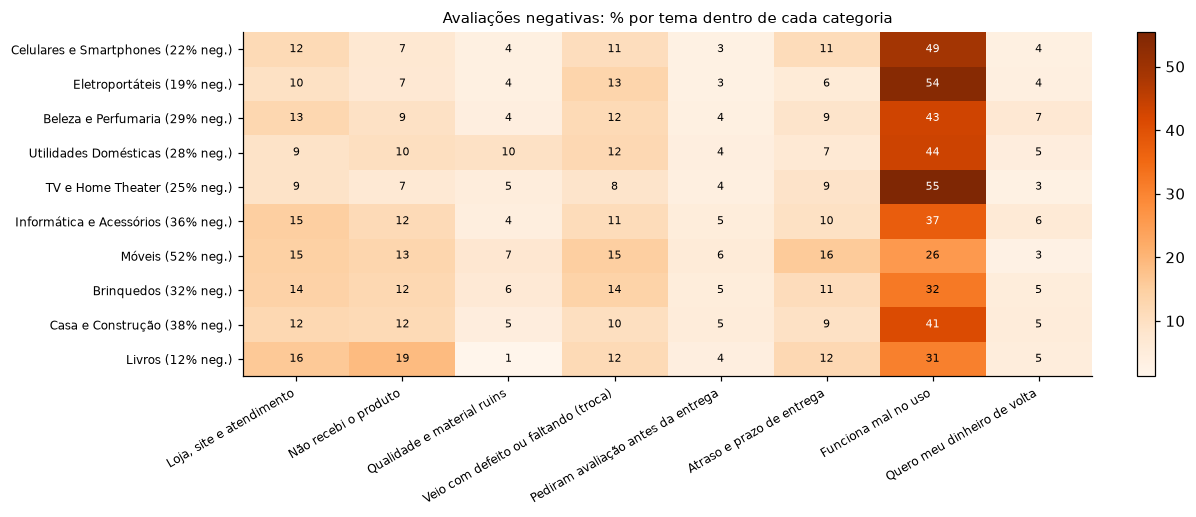

In [21]:
# ⟦célula 03.21⟧
fig, eixo = plt.subplots(figsize=(11, 4.8))
im = eixo.imshow(cruz.values, cmap="Oranges", aspect="auto")
eixo.set_xticks(range(cruz.shape[1])); eixo.set_xticklabels(cruz.columns, rotation=30, ha="right", fontsize=8)
eixo.set_yticks(range(cruz.shape[0])); eixo.set_yticklabels([f"{c} ({info.loc[c, '% negativas na categoria']:.0f}% neg.)" for c in cruz.index], fontsize=8)
for (a, b), v in np.ndenumerate(cruz.values):
    eixo.text(b, a, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > cruz.values.max() * 0.6 else "black")
eixo.grid(False); eixo.set_title("Avaliações negativas: % por tema dentro de cada categoria", fontsize=10)
fig.colorbar(im, ax=eixo, fraction=0.025); fig.tight_layout(); print(salvar(fig, "03_tema_x_categoria")); plt.show()

In [22]:
# ⟦célula 03.22⟧
# tempo: entrega piora em maio de 2018? (greve dos caminhoneiros, 21 a 31/05)
todas["mes"] = pd.to_datetime(todas["submission_date"]).dt.to_period("M").astype(str)
neg["mes"] = pd.to_datetime(neg["submission_date"]).dt.to_period("M").astype(str)
por_mes = pd.DataFrame({
    "avaliações": todas["mes"].value_counts().sort_index(),
    "% negativas": todas.groupby("mes")["classe"].apply(lambda s: (s == "negativo").mean() * 100).round(1),
    "% das avaliações = reclamação de ENTREGA": todas.groupby("mes").apply(
        lambda g: ((g["classe"] == "negativo") & (g["familia"] == "Entrega")).mean() * 100, include_groups=False).round(1),
})
por_mes

,avaliações,% negativas,% das avaliações = reclamação de ENTREGA
mes,,,
2018-01,29304,26.3,6.2
2018-02,9810,32.5,5.7
2018-03,25218,29.7,7.6
2018-04,25187,29.3,7.9
2018-05,21355,32.1,7.5


In [23]:
# ⟦célula 03.23⟧
# estado: só agregado, só estados com ≥ 1.000 avaliações (regra de dados pessoais do enunciado)
uf = todas[todas["reviewer_state"].notna()].copy()
uf["recl_entrega"] = (uf["classe"] == "negativo") & (uf["familia"] == "Entrega")
por_uf = uf.groupby("reviewer_state").agg(avaliacoes=("classe", "size"),
                                          pct_negativas=("classe", lambda s: (s == "negativo").mean() * 100),
                                          pct_reclamacao_entrega=("recl_entrega", lambda s: s.mean() * 100))
por_uf = por_uf[por_uf["avaliacoes"] >= 1000].sort_values("pct_reclamacao_entrega", ascending=False).round(1)
print(f"{len(por_uf)} estados com ≥ 1.000 avaliações")
por_uf

14 estados com ≥ 1.000 avaliações


,avaliacoes,pct_negativas,pct_reclamacao_entrega
reviewer_state,,,
MA,1001,32.2,12.6
PA,1264,30.1,12.2
CE,1835,30.5,12.2
RJ,14524,32.5,10.7
BA,3971,33.1,10.4
ES,2539,29.9,8.1
RS,5648,28.2,8.0
GO,2175,29.5,7.5
SC,3784,29.7,7.1


In [24]:
# ⟦célula 03.24⟧
# dois sinais do FORMULÁRIO de avaliação
t = df["review_text"].str.lower()
pede_antes = t.str.contains(r"(?:como|nao|não) (?:posso|tem como|da pra|dá pra|consigo) avaliar|avaliar (?:um |o )?produto que (?:ainda )?n[aã]o", regex=True)
nao_recebeu = t.str.contains(r"n[aã]o (?:recebi|chegou|foi entregue)|ainda n[aã]o (?:recebi|chegou)", regex=True)
neg_mask = df["classe"] == "negativo"
print(f"negativas que dizem que o produto NÃO CHEGOU: {(nao_recebeu & neg_mask).sum():,} = {(nao_recebeu & neg_mask).sum() / neg_mask.sum():.1%} das negativas".replace(",", "."))
print(f"avaliações que dizem 'como posso avaliar se não recebi': {pede_antes.sum():,}".replace(",", "."))

def frase_repetida(s):
    frases = [f.strip() for f in re.split(r"[.!?\n]+", s) if len(f.strip()) >= 10]
    return len(frases) != len(set(frases))
enchimento = pd.DataFrame({
    "caractere repetido 6+ vezes ('......', 'xxxxxx', 'kkkkkk')": t.map(lambda s: bool(re.search(r"(.)\1{5,}", s))),
    "'palavra' de teclado (8+ letras, 5 consoantes seguidas)": t.str.contains(r"\b(?=\w*[bcdfghjklmnpqrstvwxz]{5})[a-z]{8,}\b", regex=True),
    "a mesma frase repetida no texto": t.map(frase_repetida),
})
enchimento["qualquer um dos três"] = enchimento.any(axis=1)
resumo_ench = pd.DataFrame({"avaliações": enchimento.sum(),
                            "% positivas entre elas": [100 * (df.loc[enchimento[c], "classe"] == "positivo").mean() for c in enchimento]}).round(1)
display(resumo_ench)
df.loc[enchimento["'palavra' de teclado (8+ letras, 5 consoantes seguidas)"], "review_text"].sample(5, random_state=SEMENTE).str.slice(0, 120).to_frame()

negativas que dizem que o produto NÃO CHEGOU: 5.340 = 16.4% das negativas
avaliações que dizem 'como posso avaliar se não recebi': 842


,avaliações,% positivas entre elas
"caractere repetido 6+ vezes ('......', 'xxxxxx', 'kkkkkk')",3085,73.1
"'palavra' de teclado (8+ letras, 5 consoantes seguidas)",615,78.4
a mesma frase repetida no texto,348,68.1
qualquer um dos três,3575,72.8


,review_text
44417,Meu filho adoroooo o vídeo game foi presente de aniversário ele estava super ansioso rsrsrsrs
66783,"Produto é ótimo! Teria comprado mais duas, mas não é possível comprar mais que uma caixa por frente. Somente comprand"
77247,"produto sensacional, somente prezo de entrega não me deixou satisfeita, kkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk"
109849,Produto sensacional. Valeu a compra. xxxxxxxxxxxxxxxxxxxxxxxxxxxxx
24933,uaiii. nem recebi o produto como avaliooo ???? que mane texto curtooooo. alksdflkjaslfjlkajslfkjalskf asdflkjaslkdjflk


In [25]:
# ⟦célula 03.25⟧
# marketplace: quanto das negativas cita o vendedor parceiro / a loja / o fornecedor?
padrao_parceiro = r"\b(?:parceir\w*|lojista|vendedor\w*|fornecedor\w*|marketplace|transportadora\w*)\b"
cita = df["norm"].str.contains(padrao_parceiro, regex=True)
print(f"negativas que citam vendedor/parceiro/fornecedor/transportadora: {(cita & neg_mask).sum():,} "
      f"({(cita & neg_mask).sum() / neg_mask.sum():.1%}) · entre as positivas: {cita[~neg_mask].mean():.1%}".replace(",", "."))
df.loc[cita & neg_mask, "review_text"].sample(4, random_state=SEMENTE).str.slice(0, 200).to_frame()

negativas que citam vendedor/parceiro/fornecedor/transportadora: 2.023 (6.2%) · entre as positivas: 1.7%


,review_text
42666,"Vendedor pilantra l, antes tinha escrito fonte de 10W e eu achei q era! Tiraram agora depois q reclamei no reclame aqui!"
59240,"Eu comprei essa adega na Americanas como já havia feito com outros produtos, paguei só de frete 990,00, apesar de sempre darem um prazo máximo de entrega, minhas outras compras chegavam rápido, para m"
44510,Prazo de entrega não cumprido é crime contra o consumidor. Art. 34. O fornecedor do produto ou serviço é solidariamente responsável pelos atos de seus prepostos ou representantes autônomos. Art. 3
38496,Até o momento não recebi o produto até o momento. Gostaria que as Lojas Americanas tomasse providência com relação ao seu parceiro.


**Tema × sentimento × categoria — o que os números dizem** (⟦células 03.18 a 03.25⟧):

* **Por que não um modelo único** (⟦célula 03.18⟧): no NMF global, 9 dos 10 temas são elogio (`custo beneficio`,
  `antes prazo`, `entrega rapida`…) e as reclamações caem quase todas num tema só (30,4%: `recebi · ainda · americanas ·
  comprei`). A maioria positiva (70,6%) dita o vocabulário. É o mesmo desequilíbrio que pede o baseline ao lado da
  acurácia, agora nos temas.
* **Entrega é a família que mais pesa nos dois lados** (⟦célula 03.19⟧): **24,2% das negativas** e **21,1% das positivas**.
  Qualidade é o contrário: 21,1% das positivas e só 5,8% das negativas. **Quando o cliente reclama, ele reclama do
  serviço; quando elogia, elogia o produto e o serviço.**
* **Móveis é o caso extremo** (⟦células 03.20 e 03.21⟧): **52,4%** das avaliações da categoria são negativas, o dobro da
  média (29,4%). Entre as negativas de Móveis, os temas de entrega somam **34,3%** (Não recebi 13,0 + Avaliação antes da
  entrega 5,6 + Atraso 15,7), e *Veio com defeito ou faltando* é o maior da tabela (15,0%). O recorte da própria categoria
  mostra o que está dentro do "faltando": **peças e montagem, 32,5%** das negativas de Móveis.
* **Celulares, Eletroportáteis e TV** reclamam do **produto** (*Funciona mal no uso*: 48,9%, 53,8% e 55,4%) e muito pouco
  de entrega. Têm as menores taxas de negativas entre as grandes (19,2% a 24,7%).
* **Tempo** (⟦célula 03.22⟧): a reclamação de entrega fica entre 5,7% e 7,9% das avaliações em todos os meses. **Não
  há sinal da greve dos caminhoneiros** (21 a 31/05/2018) em maio: a base termina em 31/05, e quem comprou durante a
  greve ainda não tinha avaliado. Não dá para concluir nada sobre a greve com estes dados.
* **Estado** (⟦célula 03.23⟧, só os 14 com ≥ 1.000 avaliações): a reclamação de entrega vai de **5,2% em SP** a **12,6% no
  MA**, **12,2% no PA e no CE**, 10,7% no RJ e 10,4% na BA. **Mais que o dobro no Norte e no Nordeste**, enquanto a taxa
  geral de negativas varia pouco (26,1% a 33,1%). O problema regional é **de entrega**, não de produto.
* **Formulário** (⟦célula 03.24⟧): **5.340 negativas (16,4%)** dizem que o produto não chegou, e **842** avaliações dizem
  literalmente *"como posso avaliar se não recebi"*. Além disso, **3.575 avaliações (3,2%)** têm enchimento: caractere
  repetido (*"xxxxxxxxxx"*, *"kkkkkk"*), "palavra" de teclado (*"alksdflkjaslf"*) ou a mesma frase repetida. **72,8%**
  delas são positivas: o cliente satisfeito tem pouco a dizer e o formulário pede mais. Uma delas diz isso em voz alta:
  *"nem recebi o produto como avaliooo ???? que mané texto curtooooo. alksdflkjaslf…"*.
* **Marketplace** (⟦célula 03.25⟧): **6,2% das negativas** citam vendedor, parceiro, fornecedor ou transportadora, contra
  **1,7% das positivas**: *"Gostaria que as Lojas Americanas tomasse providência com relação ao seu parceiro"*. Somado à
  campanha de 39 cópias contra a Up2games (notebook 01, ⟦célula 01.06⟧), é sinal de que parte da nota da Americanas é
  decidida por terceiros que o cliente não distingue da loja.

---
## 7. Do texto à decisão — recomendações para a Americanas

Cinco recomendações, cada uma com o número que a sustenta, avaliações reais e o destinatário dentro da empresa.

### R1 · Parar de pedir avaliação antes da entrega — **destinatário: CRM / Marketing (e-mail de pós-venda) e Produto digital**

**O número:** o tema *"Pediram avaliação antes da entrega"* é **4,2%** das negativas (⟦célula 03.09⟧), e o tema
*"Não recebi o produto"*, **10,1%**. **5.340 avaliações negativas (16,4%)** dizem que o produto não chegou (⟦célula 03.24⟧).
São notas de 1-2 estrelas **publicadas na página de um produto que o cliente nunca viu**.
**Avaliações reais:** *"Ainda não recebi o produto e estão querendo que eu faça avaliação!!"* · *"o prazo de entrega é
tão absurdo… que me pediram pra fazer a avaliação de um produto que ainda nem teve a nota fiscal emitida"* · *"Como posso
avaliar um produto que ainda não recebi!"*
**Ação:** disparar o convite de avaliação só **depois da confirmação de entrega** e, quando o pedido atrasar, oferecer
um canal de **reclamação de entrega** em vez de um formulário de nota do produto. Ganho duplo: a nota do produto deixa de
ser punida por uma falha logística, e a queixa vai para quem pode resolvê-la.

### R2 · Móveis: checagem de volumes e peças na expedição — **destinatário: Gestão da categoria Móveis e Logística**

**O número:** Móveis tem **52,4%** de avaliações negativas, a pior taxa entre as dez maiores categorias e quase o dobro da
média de 29,4% (⟦célula 03.20⟧). No recorte da própria categoria, **"Peças faltando e montagem" é 32,5%** das negativas
(⟦célula 03.12⟧), e no recorte geral *"Veio com defeito ou faltando"* tem em Móveis o maior peso da tabela (15,0%).
**Avaliações reais:** *"ODIEI! Veio faltando muitas peças. Parafusos e a parte de trás do guarda-roupa."* · *"Veio faltando
peças! 1 mês parado sem montar"* · *"Produto maravilhoso, porém não chegou com 5 volumes, mas sim com 3 volumes e ficaram
peças de montagem faltantes"* (notebook 02, ⟦célula 02.24⟧).
**Ação:** exigir dos fornecedores de Móveis a identificação de "volume X de N" em cada caixa e conferir o número de volumes
na expedição e na entrega. Para quem já recebeu incompleto, um fluxo de **envio de peça avulsa** (com o número da peça do
manual) em vez de troca do móvel inteiro. É a categoria em que menos esforço move mais nota.

### R3 · Logística regional para Norte e Nordeste — **destinatário: Logística (malha e transportadoras)**

**O número:** a reclamação de entrega é **12,6% das avaliações no MA, 12,2% no PA e no CE e 10,4% na BA**, contra **5,2%
em SP** e 5,3% no PR (⟦célula 03.23⟧). A taxa geral de negativas varia bem menos entre esses estados (26,1% a 33,1%):
**o produto é o mesmo; a entrega, não**. No país todo, a família Entrega é 24,2% das negativas e 21,1% das positivas
(⟦célula 03.19⟧): é o fator que mais move a nota nos dois sentidos.
**Avaliações reais:** *"O prazo de entrega era pra dia 15 de fevereiro e ainda não chegou"* · *"COMPREI DIA 24/04/2018,
QUANDO COMPRA DIZ QUE É DE 07 A 10 DIAS O PRAZO DA ENTREGA… HOJE JÁ É DIA 10/05 E NADA"* · e, do lado positivo, *"Chegou
antes do prazo e o produto é o que esperava!"*.
**Ação:** revisar o **prazo prometido** para essas UFs (prometer o prazo que a malha cumpre: *"chegou antes do prazo"* é o
segundo maior tema positivo, 14,7%), e avaliar as transportadoras dessas rotas pela taxa de reclamação de entrega, usando
esta medida como indicador mensal.

### R4 · Autenticidade e curadoria de vendedores parceiros — **destinatário: Gestão do Marketplace e Categorias (Beleza, Informática)**

**O número:** em Beleza e Perfumaria, **15,2%** das negativas são sobre perfume com cheiro e fixação de "não original"; em
Informática, **15,8%** sobre cartucho "falsificado" (⟦célula 03.12⟧). **6,2% das negativas** citam vendedor, parceiro,
fornecedor ou transportadora, contra 1,7% das positivas (⟦célula 03.25⟧), e a auditoria achou **39 cópias** do mesmo
protesto contra um vendedor (⟦célula 01.06⟧).
**Avaliações reais:** *"O perfume não é original. Uso esse perfume há bastante tempo, e esse que comprei não tem fixação
nenhuma."* · *"a impressora acusa como cartucho falsificado"* · *"Lojas Americanas está expondo produto falsificado em seu
site."* · *"Gostaria que as Lojas Americanas tomasse providência com relação ao seu parceiro."*
**Ação:** monitorar, por vendedor, a taxa de avaliações com os termos de autenticidade (`original`, `falsificado`,
`fixação`) e suspender ofertas acima de um limiar. Mostrar com mais clareza na página **quem vende** e **quem entrega**: o
cliente atribui à Americanas a falha do parceiro.

### R5 · Simplificar o formulário de avaliação — **destinatário: Produto digital / UX**

**O número:** **3.575 avaliações (3,2%)** têm texto de enchimento (*"xxxxxxxx"*, *"alksdflkjaslf"*, frase repetida), e
**72,8%** delas são positivas (⟦célula 03.24⟧). Dois temas positivos inteiros (*"Recomendo"*, 26,5%, e *"Bom"*, 17,6%) são
em parte esse enchimento (⟦célula 03.11⟧).
**Avaliações reais:** *"Produto sensacional. Valeu a compra. xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"* · *"Recomendo vgfrgjkgfewsdgj
dfgjihfeesfjj…"* · *"que mané texto curtooooo. alksdflkjaslfjlkajslfkjalskf"*.
**Ação:** remover (ou reduzir muito) o **tamanho mínimo** do texto e separar a avaliação em perguntas curtas: produto,
entrega e vendedor. A base perde lixo, o cliente satisfeito avalia mais rápido, e as reclamações de entrega (R1, R3) deixam
de contaminar a nota do produto.

---
## 8. Limites — o que estes dados NÃO permitem concluir

* **A base é de 2018** (01/01 a 31/05). Malha logística, vendedores do marketplace e o próprio formulário podem ter mudado.
  As recomendações são hipóteses a verificar com dados atuais, e não diagnóstico do presente.
* **Só quem avaliou está na base.** Quem teve problema e desistiu, ou quem ficou satisfeito e não escreveu, não aparece. As
  porcentagens são **das avaliações**, não **dos pedidos**: "16,4% das negativas dizem que não chegou" **não** quer dizer
  que 16,4% dos pedidos não chegaram.
* **Não há preço, nem resposta da loja, nem devolução registrada, nem identificação do vendedor.** Não dá para saber se o
  produto mais barato é o mais criticado, se a reclamação foi resolvida, quantas devoluções houve ou **qual** parceiro é o
  problema (fora a campanha contra a Up2games, que só aparece porque o cliente escreveu o nome).
* **Nada aqui é causal.** A taxa maior de reclamação de entrega no MA mostra **onde** olhar, não **por que** acontece.
* **O tema de cada avaliação é o dominante** de uma mistura. Uma avaliação sobre atraso *e* defeito conta só para um deles.
  O tema *"Funciona mal no uso"* (40,8% das negativas) é largo e reúne defeitos muito diferentes; a seção 4 só o abre para
  quatro categorias.
* **As contagens por expressão regular são aproximadas** (enchimento, "não recebi", menção a parceiro): têm falsos
  positivos (`rsrsrsrs` conta como "palavra de teclado") e falsos negativos (quem escreve "não veio" sem as palavras da regex).
* **Estado, gênero e idade são autodeclarados** e foram usados só em agregados com ≥ 1.000 avaliações, sem associar perfil a
  avaliação individual. O ano de nascimento tem erros (mínimo 59, 108 anos impossíveis), e por isso a idade não foi usada.
* **A greve dos caminhoneiros** (21 a 31/05/2018) cai no fim da base. A ausência de efeito em maio **não** prova que ela não
  afetou entregas: as avaliações chegam depois da entrega, e a base acaba antes.

In [26]:
# ⟦célula 03.26⟧
joblib.dump({"negativo": {"vetorizador": vetN, "nmf": nmfN, "nomes": NOMES_NEG, "familia": FAMILIA_NEG},
             "positivo": {"vetorizador": vetP, "nmf": nmfP, "nomes": NOMES_POS, "familia": FAMILIA_POS},
             "stop_temas": sorted(STOP_TEMAS)}, "app/modelos/temas.joblib", compress=3)
todas[["linha_original", "classe", "tema", "nome_tema", "familia"]].to_parquet("artefatos/temas_por_avaliacao.parquet", index=False)
print(f"app/modelos/temas.joblib · {Path('app/modelos/temas.joblib').stat().st_size / 1e6:.1f} MB")

app/modelos/temas.joblib · 1.0 MB


---
## Ficha de decisões dos temas (no formato da Prática 03)

| etapa | o que fizemos | por quê |
|---|---|---|
| limpeza para temas | NLTK completa + 20 genéricas do domínio, letra esticada colapsada | com as protegidas do classificador, 3 temas-artefato (função 37,8%, tempo 8,1%, polaridade 15,3%) — ⟦03.04⟧ |
| representação | TF-IDF (1,2), `min_df=10`, `max_df=0,5` | a do notebook 02, com `max_df` para cortar o vocabulário de qualquer avaliação |
| método | NMF, `init="nndsvd"`, `random_state=42` | determinístico, pesos não negativos legíveis; texto é mistura de temas (contraprova) |
| k | 8 nas negativas e nas positivas; 5 por categoria | positivas: a redundância dobra em k = 10; negativas: k = 8 separa atraso, loja e reembolso, que k = 5 junta — ⟦03.06 a 03.08⟧ |
| teste de sanidade | Ward e K-Means em 3.000 negativas (LSA 100d), contra a mesma matriz embaralhada | silhueta baixa mas acima do embaralhado; Ward reencontra 5 dos 8 temas — ⟦03.16, 03.17⟧ |
| hierárquico × NMF | NMF vai para o relatório; hierárquico é contraprova | não há salto nem grupos compactos: a árvore parece a da base sem estrutura — ⟦03.14⟧ |
| cruzamento | dois modelos por polaridade + famílias de assunto | o modelo global foi dominado pela maioria positiva — ⟦03.18⟧ |